# Análisis del Dataset Auto (R)
## Información General
Este notebook contiene el análisis completo solicitado utilizando el lenguaje **R** y el dataset `Auto` del paquete `ISLR2`.


In [1]:
library(ISLR2)
library(ggplot2)
library(dplyr)

# Cargar los datos
data("Auto")

# Formatear la variable origen a un factor textual
Auto$origin <- factor(Auto$origin, levels = c(1, 2, 3), labels = c("usa", "europe", "japan"))

head(Auto)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
,<dbl>,<int>,<dbl>,<int>,<int>,<dbl>,<int>,<fct>,<fct>
1,18,8,307,130,3504,12.0,70,usa,chevrolet chevelle malibu
2,15,8,350,165,3693,11.5,70,usa,buick skylark 320
3,18,8,318,150,3436,11.0,70,usa,plymouth satellite
4,16,8,304,150,3433,12.0,70,usa,amc rebel sst
5,17,8,302,140,3449,10.5,70,usa,ford torino
6,15,8,429,198,4341,10.0,70,usa,ford galaxie 500


## Exploración Inicial


In [2]:
cat("¿Cuántas filas y columnas tiene el dataset?\n")
cat("Filas:", nrow(Auto), "Columnas:", ncol(Auto), "\n\n")

cat("¿Qué variables numéricas contiene?\n")
cat(names(Auto)[sapply(Auto, is.numeric)], sep=", ", "\n\n")

cat("¿Existen valores nulos? ¿En qué columnas?\n")
col_nulos <- colSums(is.na(Auto))
if(sum(col_nulos) == 0) {
  cat("No hay valores nulos en este dataset (ISLR2 remueve los registros con NA en horsepower).\n")
} else {
  print(col_nulos[col_nulos > 0])
}


¿Cuántas filas y columnas tiene el dataset?
Filas: 392 Columnas: 9 

¿Qué variables numéricas contiene?
mpg, cylinders, displacement, horsepower, weight, acceleration, year, 

¿Existen valores nulos? ¿En qué columnas?
No hay valores nulos en este dataset (ISLR2 remueve los registros con NA en horsepower).


**Respuestas de exploración inicial:**
- **Filas y columnas:** 392 filas y 9 columnas. (Diferencia con seaborn: aquí ya se han filtrado las 6 filas con NAs).
- **Variables numéricas:** mpg, cylinders, displacement, horsepower, weight, acceleration, year.
- **Valores nulos:** Ninguno.
- **Variable a analizar:** `mpg` (rendimiento de combustible).

**Paso 1: Selección de la Variable**
Variable elegida: **mpg (rendimiento de combustible)**


## Paso 2: Medidas Descriptivas Previas


In [3]:
var_analisis <- Auto$mpg
n <- length(var_analisis)
minimo <- min(var_analisis)
maximo <- max(var_analisis)
rango <- maximo - minimo
media <- mean(var_analisis)
mediana <- median(var_analisis)
desv_est <- sd(var_analisis)
cv <- (desv_est / media) * 100

cat("Tabla de resultados con las medidas fundamentales:\n")
cat("n (tamaño de muestra):", n, "\n")
cat("Mínimo:", minimo, "\n")
cat("Máximo:", maximo, "\n")
cat("Rango (R):", round(rango, 2), "\n")
cat("Media (x̄):", round(media, 2), "\n")
cat("Mediana:", round(mediana, 2), "\n")
cat("Desviación estándar (s):", round(desv_est, 2), "\n")
cat("Coeficiente de variación (CV %):", round(cv, 2), "%\n")


Tabla de resultados con las medidas fundamentales:
n (tamaño de muestra): 392 
Mínimo: 9 
Máximo: 46.6 
Rango (R): 37.6 
Media (x̄): 23.45 
Mediana: 22.75 
Desviación estándar (s): 7.81 
Coeficiente de variación (CV %): 33.29 %


**Interpretación de las medidas descriptivas:**
El análisis del rendimiento de combustible (mpg) muestra que en esta muestra de 392 vehículos, los valores oscilan entre 9.0 y 46.6 millas por galón. La media es de 23.45 y la mediana es 22.75, indicando un leve sesgo a la derecha. El coeficiente de variación del 33.31% señala una dispersión moderada, propia de un mercado automotor que combina autos de alto consumo con vehículos compactos y económicos.


## Creación de Tabla de Frecuencias


In [4]:
# Regla de Sturges para número de clases
k <- ceiling(1 + 3.322 * log10(n))
w <- rango / k
cat("Número de intervalos (k):", k, "\n")
cat("Amplitud (w):", round(w, 2), "\n\n")

cortes <- seq(minimo, maximo, length.out = k + 1)
Auto$mpg_bins <- cut(Auto$mpg, breaks = cortes, include.lowest = TRUE, right = FALSE)

# Crear la tabla de frecuencias
tabla_frecuencia <- as.data.frame(table(Auto$mpg_bins))
colnames(tabla_frecuencia) <- c("mpg_bins", "Frecuencia (f)")
tabla_frecuencia$`Frecuencia Acumulada (F)` <- cumsum(tabla_frecuencia$`Frecuencia (f)`)
tabla_frecuencia$`Frecuencia Relativa (%)` <- (tabla_frecuencia$`Frecuencia (f)` / n) * 100
tabla_frecuencia$`Frec. Relativa Acumulada (%)` <- cumsum(tabla_frecuencia$`Frecuencia Relativa (%)`)

# Marca de clase
obtener_marca_clase <- function(intervalo) {
  num_str <- gsub("\\[|\\)|\\]", "", as.character(intervalo))
  nums <- as.numeric(unlist(strsplit(num_str, ",")))
  return(mean(nums))
}
tabla_frecuencia$`Marca de Clase (x)` <- sapply(tabla_frecuencia$mpg_bins, obtener_marca_clase)

print(tabla_frecuencia)


Número de intervalos (k): 10 
Amplitud (w): 3.76 

      mpg_bins Frecuencia (f) Frecuencia Acumulada (F) Frecuencia Relativa (%)
1     [9,12.8)             13                       13                3.316327
2  [12.8,16.5)             78                       91               19.897959
3  [16.5,20.3)             73                      164               18.622449
4    [20.3,24)             58                      222               14.795918
5    [24,27.8)             53                      275               13.520408
6  [27.8,31.6)             48                      323               12.244898
7  [31.6,35.3)             37                      360                9.438776
8  [35.3,39.1)             22                      382                5.612245
9  [39.1,42.8)              4                      386                1.020408
10 [42.8,46.6]              6                      392                1.530612
   Frec. Relativa Acumulada (%) Marca de Clase (x)
1                      3.3163

## Paso 3: Visualización
Histograma y Gráfico de líneas para el porcentaje acumulado (Ojiva)


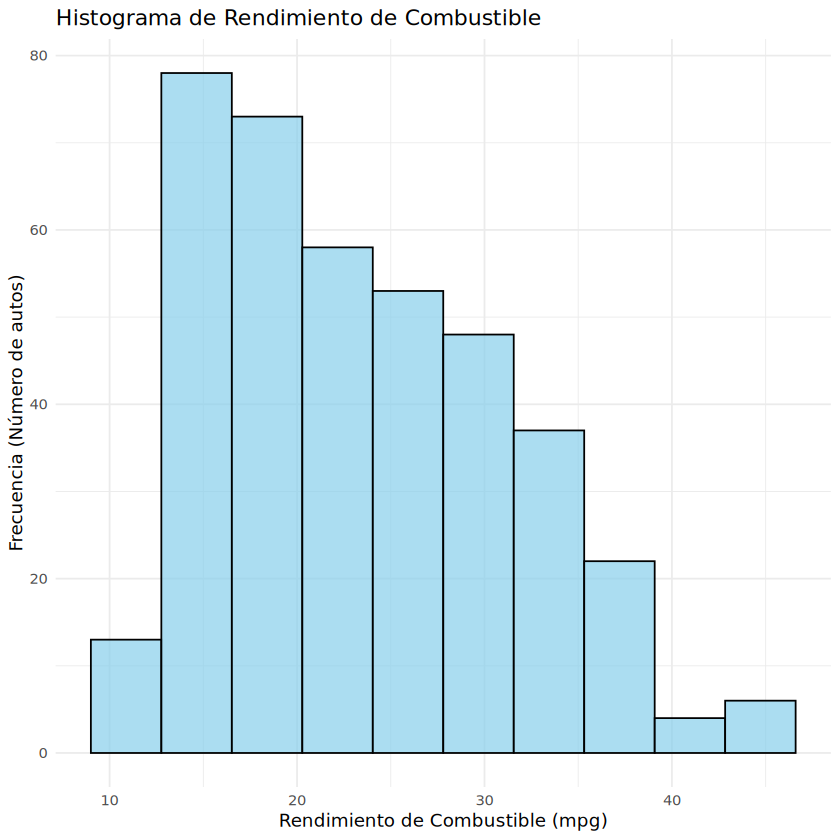

In [5]:
# Histograma
ggplot(Auto, aes(x=mpg)) +
  geom_histogram(breaks=cortes, fill="skyblue", color="black", alpha=0.7) +
  labs(title="Histograma de Rendimiento de Combustible", x="Rendimiento de Combustible (mpg)", y="Frecuencia (Número de autos)") +
  theme_minimal()


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


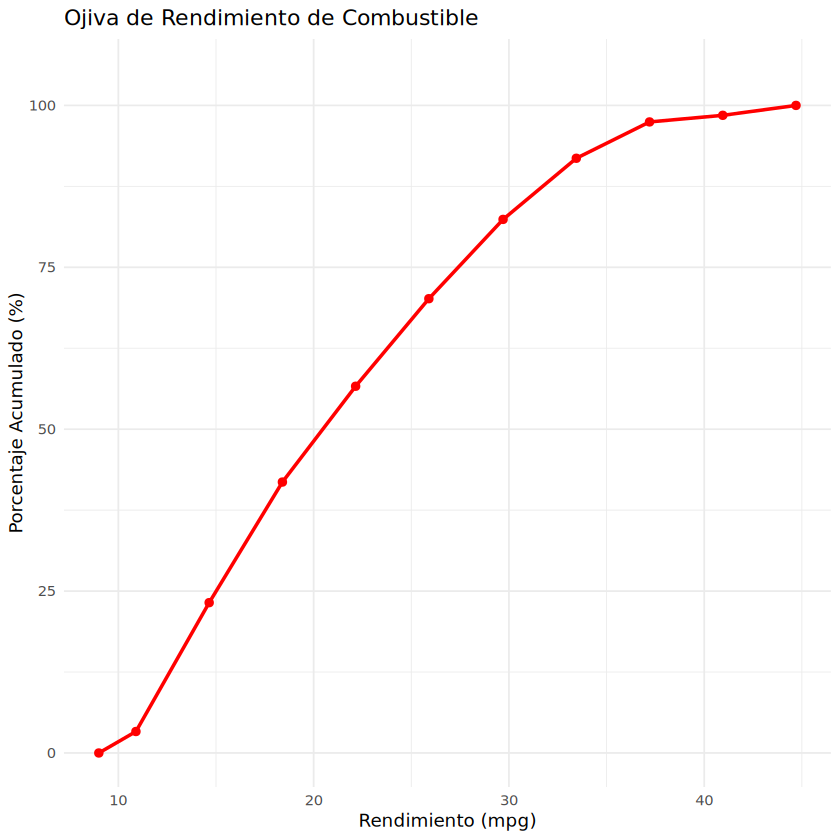

In [6]:
# Ojiva (Porcentaje Acumulado)
# Se agrega un punto de origen en cero
puntos_ojiva <- data.frame(
  x = c(minimo, tabla_frecuencia$`Marca de Clase (x)`),
  y = c(0, tabla_frecuencia$`Frec. Relativa Acumulada (%)`)
)

ggplot(puntos_ojiva, aes(x=x, y=y)) +
  geom_line(color="red", size=1) +
  geom_point(color="red", size=2) +
  labs(title="Ojiva de Rendimiento de Combustible", x="Rendimiento (mpg)", y="Porcentaje Acumulado (%)") +
  ylim(0, 105) +
  theme_minimal()


**Análisis de la forma de la distribución:**
- **¿Es simétrica o sesgada?** Es sesgada hacia la derecha (asimetría positiva).
- **¿Hacia qué lado se concentra la mayor frecuencia?** Hacia la izquierda, en los valores de menor rendimiento (entre 13 y 20 mpg).
- **¿Hay valores atípicos visibles?** Sí, los valores por encima de 40 mpg actúan como una pequeña cola atípica de alta eficiencia.


## Paso 4: Interpretación de Resultados (Requerimiento Obligatorio)
**Contexto de la variable:** La variable analizada es *mpg*, midiendo el rendimiento de combustible en millas por galón, vital para conocer la eficiencia energética de un vehículo.
**Tendencia central:** La media de 23.45 y la mediana de 22.75 revelan que el vehículo típico del dataset es de rendimiento moderado-bajo. Esta diferencia muestra una distribución empujada hacia arriba por unos pocos autos muy eficientes.
**Dispersión:** El coeficiente de variación cercano al 33% indica que los datos son bastante variables, abarcando desde grandes motores poco eficientes hasta autos livianos muy económicos.
**Conclusión general:** El dataset refleja una industria automotriz polarizada (típico de los años 70 y 80) donde abundaban autos gastadores de combustible, pero en medio de una transición emergente hacia modelos japoneses o europeos más eficientes.


## Paso 5: Preguntas de Reflexión
- **¿Qué información aporta la ojiva que no aporta el histograma?** Aporta visibilidad instantánea de los percentiles. Puedes saber de inmediato el porcentaje total de autos por debajo de un consumo particular, algo que en un histograma exigiría calcular y sumar áreas mentalmente.
- **¿Cómo usaría las tablas de frecuencia para comparar dos modelos de autos?** Separaría el dataset (ej: 4 vs 8 cilindros), crearía dos columnas de frecuencias relativas para los mismos rangos de clase, y compararía en qué intervalo se concentra la mayoría en cada grupo.


## Paso 6: Análisis Comparativo

### Pregunta 1: ¿Existen diferencias en el rendimiento (mpg) según el número de cilindros?
**Tipo de análisis:** Comparación entre grupos


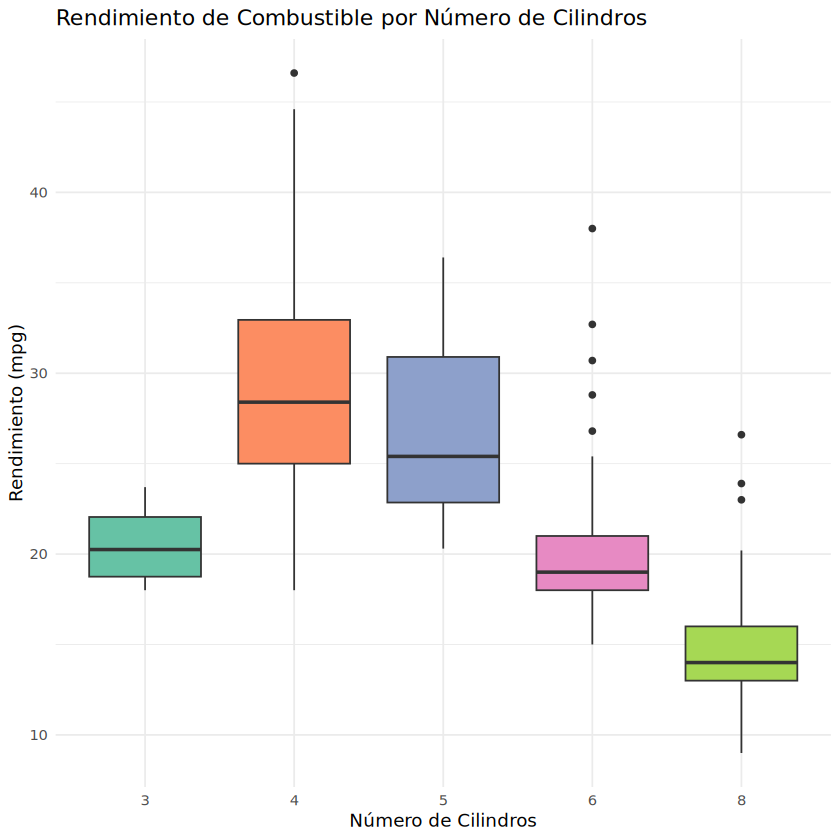

In [7]:
ggplot(Auto, aes(x=as.factor(cylinders), y=mpg, fill=as.factor(cylinders))) +
  geom_boxplot() +
  labs(title="Rendimiento de Combustible por Número de Cilindros", x="Número de Cilindros", y="Rendimiento (mpg)") +
  scale_fill_brewer(palette="Set2") +
  theme_minimal() + guides(fill="none")


**Interpretación técnica:**
- **¿Cómo varía la mediana?** Disminuye de forma monótona a medida que aumentan los cilindros.
- **¿Qué grupo presenta mayor dispersión?** Los autos de 4 cilindros tienen cajas y bigotes más amplios, sugiriendo alta variabilidad tecnológica en esa categoría.
- **¿Hay solapamiento entre las cajas?** Entre 4 y 8 cilindros no hay solapamiento, demostrando una diferencia de distribuciones estadísticamente significativa.
- **Hipótesis:** $H_0$: $\mu_{4cil} = \mu_{6cil} = \mu_{8cil}$. La varianza entre grupos es suficientemente grande respecto a la varianza intra-grupos para ser rechazada en un ANOVA.


### Pregunta 2: ¿Existen diferencias significativas en el rendimiento según el país de origen?
**Tipo de análisis:** Comparación entre grupos


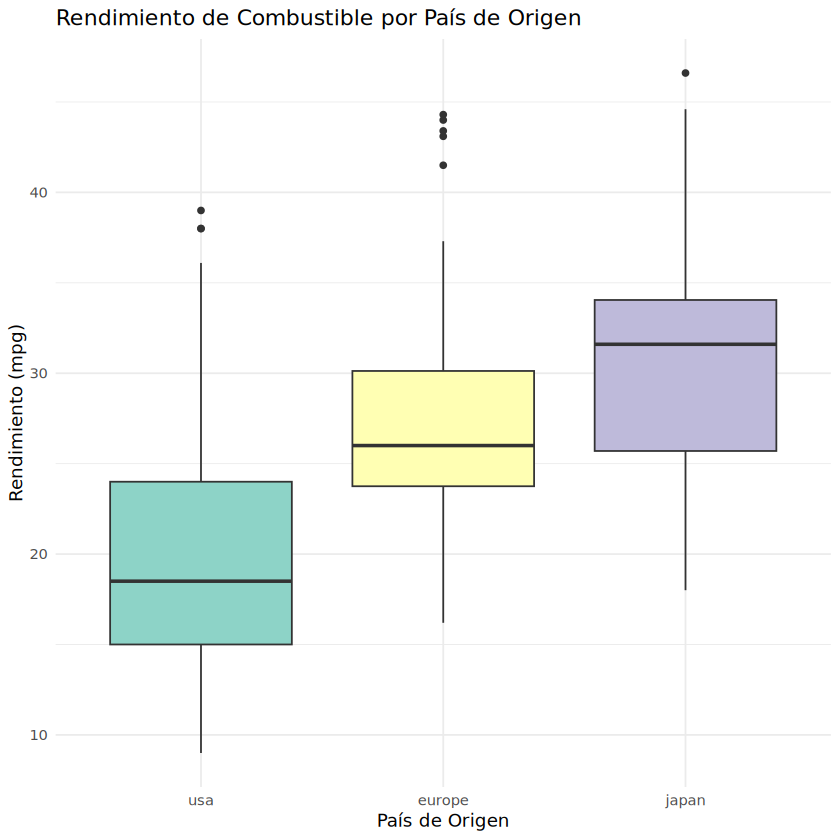

In [8]:
ggplot(Auto, aes(x=origin, y=mpg, fill=origin)) +
  geom_boxplot() +
  labs(title="Rendimiento de Combustible por País de Origen", x="País de Origen", y="Rendimiento (mpg)") +
  scale_fill_brewer(palette="Set3") +
  theme_minimal() + guides(fill="none")


**Interpretación técnica:**
- **¿Qué origen tiene mejor y peor rendimiento?** "Japan" tiene el mejor promedio/mediana, "usa" el peor.
- **¿La forma de las distribuciones es similar?** Las asimetrías varían, USA está más sesgada con atípicos superiores.
- **¿Los datos sugieren igualdad de varianzas?** Hay indicios de heterocedasticidad, ya que el rango intercuartílico de los europeos y usa parece variar ligeramente.
- **Variables de confusión:** El peso (`weight`) y el número de cilindros (`cylinders`) confunden el análisis, pues USA construía autos sistemáticamente más grandes.


### Pregunta 3: ¿Cómo interactúan el origen y el número de cilindros sobre el rendimiento?
**Tipo de análisis:** Comparación multivariada categórica


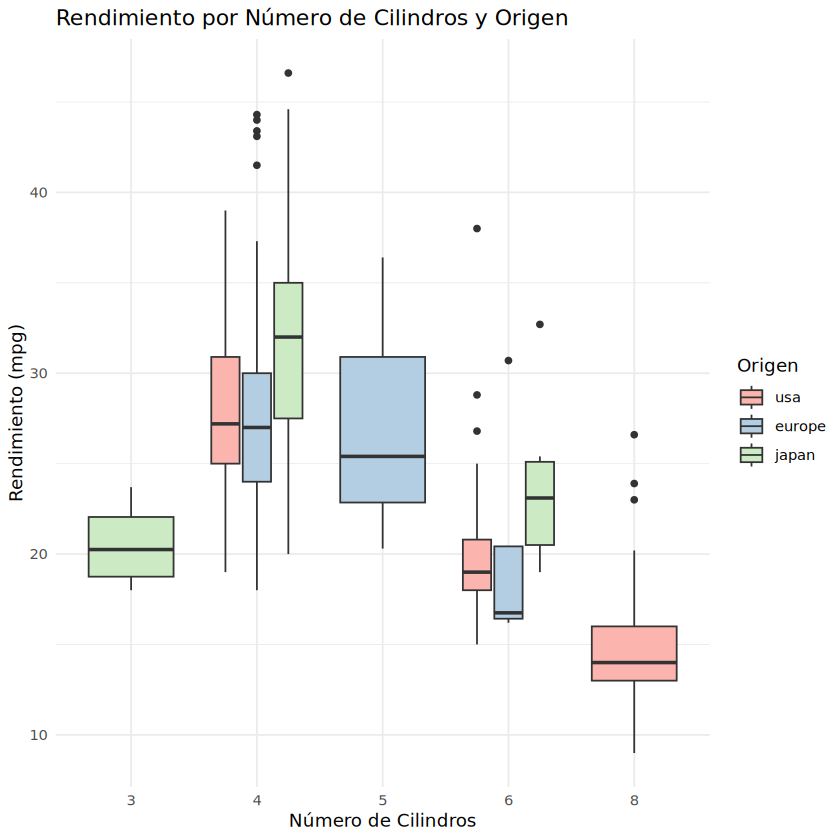

In [9]:
ggplot(Auto, aes(x=as.factor(cylinders), y=mpg, fill=origin)) +
  geom_boxplot() +
  labs(title="Rendimiento por Número de Cilindros y Origen", x="Número de Cilindros", y="Rendimiento (mpg)", fill="Origen") +
  scale_fill_brewer(palette="Pastel1") +
  theme_minimal()


**Interpretación técnica:**
- **¿El efecto de los cilindros es constante?** Sí, más cilindros reducen el rendimiento para cualquier origen, pero se evidencia que Japón no aportó autos de 8 cilindros.
- **Comportamiento diferenciado:** Comparando peras con peras (los autos de 4 cilindros), Japón sigue liderando la eficiencia sobre USA, demostrando superioridad en optimización de motores pequeños.
- **Ventajas del gráfico:** Desagrega las variables confundidas y revela la verdadera procedencia de la ineficiencia americana (su monopolio de modelos de 8 cilindros y su rezago en los de 4).


### Pregunta 4: ¿Cómo ha cambiado la composición de cilindros y orígenes por año?
**Tipo de análisis:** Composición por categorías en el tiempo


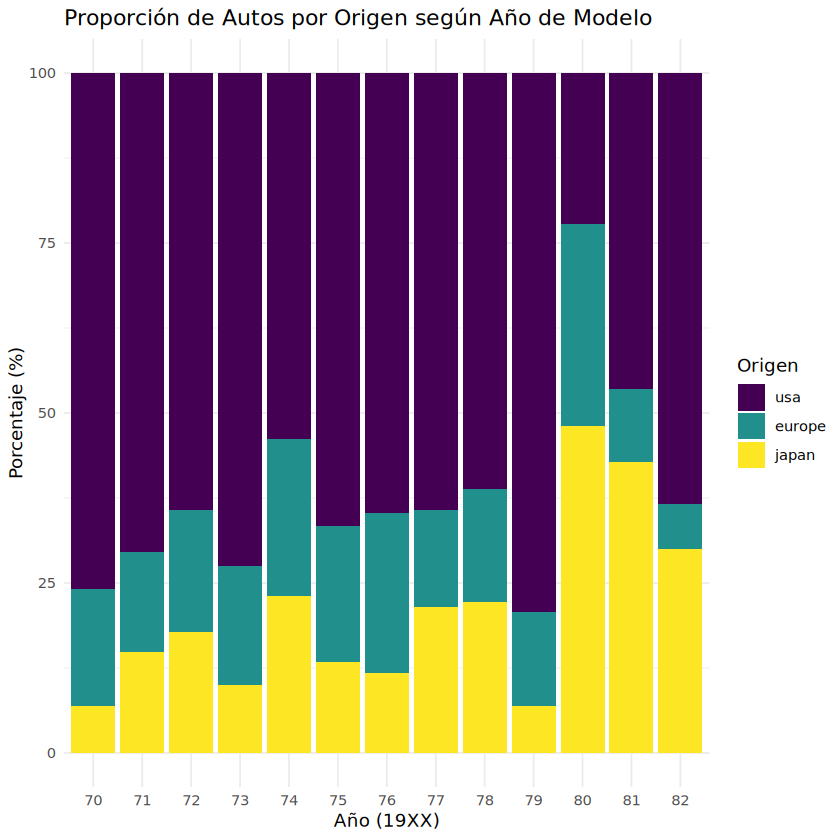

In [10]:
prop_data <- Auto %>%
  group_by(year, origin) %>%
  summarise(count = n(), .groups = 'drop') %>%
  group_by(year) %>%
  mutate(percent = count / sum(count) * 100)

ggplot(prop_data, aes(x=as.factor(year), y=percent, fill=origin)) +
  geom_bar(stat="identity") +
  labs(title="Proporción de Autos por Origen según Año de Modelo", x="Año (19XX)", y="Porcentaje (%)", fill="Origen") +
  scale_fill_viridis_d() +
  theme_minimal()


**Interpretación técnica:**
- **¿Cómo ha evolucionado?** La cuota de mercado japonesa aumentó notoriamente hacia los años 1980, robando proporción a USA.
- **¿Disminuyeron los 8 cilindros?** Al bajar el porcentaje de autos norteamericanos (los únicos con 8 cilindros en este estudio), inferimos un retroceso de los motores V8, coincidiendo con la crisis petrolera.
- **Relación con tendencia:** Este auge importador de autos chicos y eficientes japoneses es el catalizador que elevó la media general del mpg a lo largo del periodo.


## Paso 7: Diseño de su Propio Análisis
**Pregunta de análisis propuesta:** ¿Cómo se correlaciona el peso del vehículo (weight) con su eficiencia de combustible (mpg) y cómo segregan los países de origen en esta relación geométrica?

**Variables involucradas:**
- Eje X: `weight` (Peso del vehículo, lbs)
- Eje Y: `mpg` (Rendimiento de combustible)
- Color/grupo: `origin` (País de origen)
- Tamaño del punto: `horsepower` (Caballos de fuerza)

**Tipo de gráfico seleccionado y justificación:** Un Scatter Plot (gráfico de dispersión) multivariado. Es ideal porque mapea la relación no lineal continua entre consumo y peso, revelando "clusters" mediante el uso del color para el origen, y el tamaño de burbuja añade contexto al mostrar si el motor es grande (alta potencia).


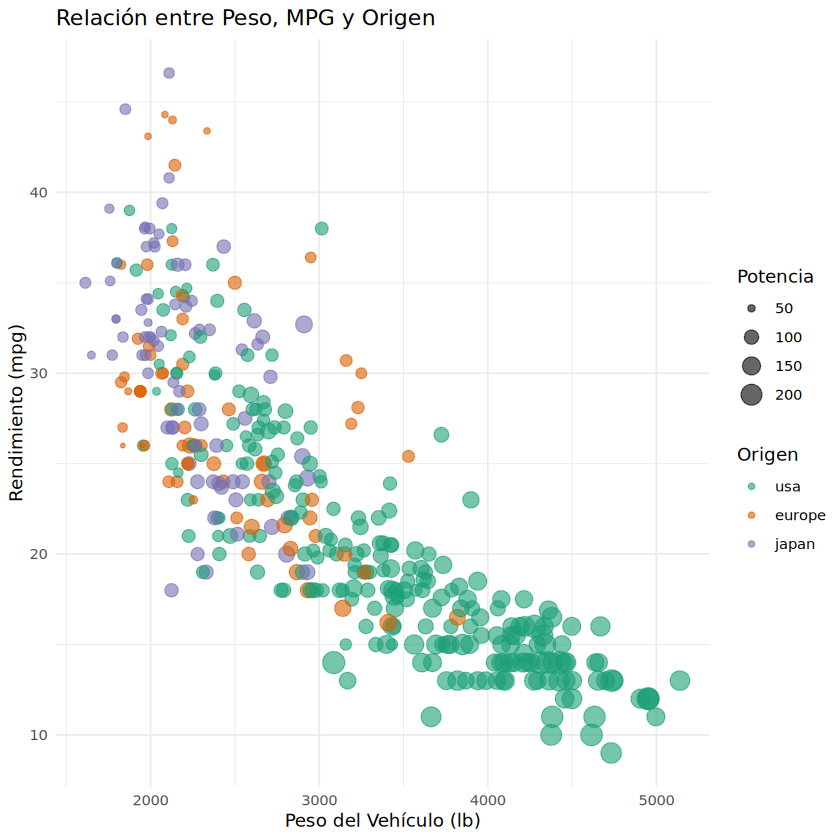

In [11]:
ggplot(Auto, aes(x=weight, y=mpg, color=origin, size=horsepower)) +
  geom_point(alpha=0.6) +
  labs(title="Relación entre Peso, MPG y Origen", x="Peso del Vehículo (lb)", y="Rendimiento (mpg)", color="Origen", size="Potencia") +
  scale_color_brewer(palette="Dark2") +
  theme_minimal()


**Interpretación técnica:**
Existe una marcada correlación negativa y curvilínea (asíntota) entre peso y rendimiento: los kilos penalizan severamente los mpg.
El agrupamiento espacial (clusters) es innegable: Estados Unidos monopoliza la porción de alto peso y baja eficiencia (>3500 lbs), mientras Europa y Japón se concentran sólidamente en el rango ultra eficiente y liviano.
Todos los países obedecen a la misma curva de la física, pero se posicionaron estratégicamente en cuadrantes diametralmente opuestos del diseño mecánico automotriz.

## Matriz de Autoevaluación
- El título describe qué se muestra <span style="color:green">(satisfied)</span>
- Los ejes tienen etiquetas con unidades <span style="color:green">(satisfied)</span>
- La escala del eje Y comienza en cero o es correcta al contexto <span style="color:green">(satisfied)</span>
- El uso del color es informativo, no decorativo <span style="color:green">(satisfied)</span>
- Se incluye leyenda cuando hay múltiples grupos <span style="color:green">(satisfied)</span>
- No hay "chartjunk" <span style="color:green">(satisfied)</span>
- El tipo de gráfico corresponde a la naturaleza de las variables <span style="color:green">(satisfied)</span>
